# Alzheimer's Disease MRI Dataset — Exploratory Data Analysis

**Objective:** Systematically audit the MRI image dataset before model training.

| Section | Analysis |
|---------|----------|
| 1 | Environment setup & imports |
| 2 | Dataset loading via `ImageFolder` |
| 3 | Class distribution |
| 4 | Sample image visualisation |
| 5 | Image dimension audit |
| 6 | Corrupted image detection |
| 7 | Pixel-level statistics |
| 8 | Publication-quality summary figure |

**Expected folder layout:**
```
Data/
├── Mild Dementia/
├── Moderate Dementia/
├── Non Demented/
└── Very mild Dementia/
```

---
## Cell 1 — Environment Setup & Imports

In [13]:
!pip install torch torchvision tqdm --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
# ── Install (run once; comment out if already installed) ───────────────────
# !pip install torch torchvision Pillow pandas numpy matplotlib seaborn tqdm

import io
import os
import re
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
import torch
from torchvision import datasets, transforms
from torchvision.utils import make_grid

warnings.filterwarnings("ignore")

# ── Global aesthetics ──────────────────────────────────────────────────────
# Palette: clinical navy, slate, soft red, teal, amber — avoids the generic
# matplotlib defaults while remaining accessible and print-safe.
PALETTE = {
    "Mild Dementia":      "#E07B54",   # warm terracotta
    "Moderate Dementia":  "#C0392B",   # deep red
    "Non Demented":       "#2E86AB",   # clinical blue
    "Very mild Dementia": "#F4A261",   # amber
}
CLASS_ORDER = ["Non Demented", "Very mild Dementia", "Mild Dementia", "Moderate Dementia"]

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    False,
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
})

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"PyTorch {torch.__version__} | PIL {Image.__version__}")
print("Environment ready.")

PyTorch 2.12.1+cpu | PIL 12.0.0
Environment ready.


---
## Cell 2 — Dataset Loading via `ImageFolder`

In [6]:
# ── Cell 2 — Dataset Loading via ImageFolder ──────────────────────────────
import zipfile
from pathlib import Path

# ── Step 1: Extract zip if needed ─────────────────────────────────────────
ZIP_PATH    = Path(r"C:\Users\MUKESH KANNA P K\Downloads\archive.zip")
EXTRACT_DIR = Path(r"C:\Users\MUKESH KANNA P K\Downloads\alzheimer_data")

if not EXTRACT_DIR.exists():
    print(f"Extracting {ZIP_PATH.name} …")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print(f"Done. Extracted to: {EXTRACT_DIR}")
else:
    print(f"Extraction folder already exists: {EXTRACT_DIR}")

# ── Step 2: Auto-locate the folder that holds the four class subfolders ───
EXPECTED_CLASSES = {"Mild Dementia", "Moderate Dementia",
                    "Non Demented", "Very mild Dementia"}

DATA_DIR = None
for candidate in [EXTRACT_DIR, *EXTRACT_DIR.rglob("*")]:
    if candidate.is_dir():
        subdirs = {d.name for d in candidate.iterdir() if d.is_dir()}
        if EXPECTED_CLASSES.issubset(subdirs):
            DATA_DIR = candidate
            break

if DATA_DIR is None:
    # Show what was actually extracted to help you find the right path
    print("\n⚠️  Could not find the four class folders automatically.")
    print("Folders found inside the extraction directory:")
    for d in sorted(EXTRACT_DIR.rglob("*")):
        if d.is_dir():
            print(f"   {d}")
    raise FileNotFoundError(
        "Set DATA_DIR manually to the folder that contains "
        "'Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia'."
    )

print(f"\n✓ DATA_DIR resolved to: {DATA_DIR}")

# ── Step 3: Load via ImageFolder ──────────────────────────────────────────
base_tfm = transforms.Compose([transforms.ToTensor()])
dataset  = datasets.ImageFolder(root=str(DATA_DIR), transform=base_tfm)

classes      = dataset.classes
class_to_idx = dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
all_paths    = [s[0] for s in dataset.samples]
all_labels   = [s[1] for s in dataset.samples]

print("=" * 52)
print(f"  Root directory : {DATA_DIR}")
print(f"  Total images   : {len(dataset):,}")
print(f"  Classes ({len(classes)})    : {classes}")
print("=" * 52)

# ── Step 4: Build master inventory DataFrame ──────────────────────────────
import re

_OASIS_RE = re.compile(r"(OAS\d+_\d+_MR\d+)", re.IGNORECASE)

inventory_df = pd.DataFrame({
    "image_path" : all_paths,
    "label_idx"  : all_labels,
    "class_name" : [idx_to_class[i] for i in all_labels],
    "filename"   : [Path(p).name    for p in all_paths],
})

inventory_df["subject_id"] = inventory_df["filename"].apply(
    lambda fn: (m := _OASIS_RE.search(fn)) and m.group(1).upper() or "UNKNOWN"
)

print(f"\n  Unique subjects : {inventory_df['subject_id'].nunique()} "
      f"({'UNKNOWN' if (inventory_df['subject_id'] == 'UNKNOWN').all() else 'OASIS IDs found'})")
print(f"  Inventory shape : {inventory_df.shape}")
print()
display(inventory_df.head(4))

Extraction folder already exists: C:\Users\MUKESH KANNA P K\Downloads\alzheimer_data

✓ DATA_DIR resolved to: C:\Users\MUKESH KANNA P K\Downloads\alzheimer_data\Data
  Root directory : C:\Users\MUKESH KANNA P K\Downloads\alzheimer_data\Data
  Total images   : 86,437
  Classes (4)    : ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

  Unique subjects : 366 (OASIS IDs found)
  Inventory shape : (86437, 5)



,image_path,label_idx,class_name,filename,subject_id
0,C:\Users\MUKESH KANNA P K\Downloads\alzheimer_...,0,Mild Dementia,OAS1_0028_MR1_mpr-1_100.jpg,OAS1_0028_MR1
1,C:\Users\MUKESH KANNA P K\Downloads\alzheimer_...,0,Mild Dementia,OAS1_0028_MR1_mpr-1_101.jpg,OAS1_0028_MR1
2,C:\Users\MUKESH KANNA P K\Downloads\alzheimer_...,0,Mild Dementia,OAS1_0028_MR1_mpr-1_102.jpg,OAS1_0028_MR1
3,C:\Users\MUKESH KANNA P K\Downloads\alzheimer_...,0,Mild Dementia,OAS1_0028_MR1_mpr-1_103.jpg,OAS1_0028_MR1


### 📝 Observation — Dataset Loading


```
Total images loaded   : 86437
Classes detected      : Mild Dementia | Moderate Dementia | Non Demented | Very mild Dementia
OASIS subject IDs     : 366 unique subjects found (UNKNOWN = non-OASIS filename)
```



---
## Cell 3 — Class Distribution

Saved → outputs\01_class_distribution.png


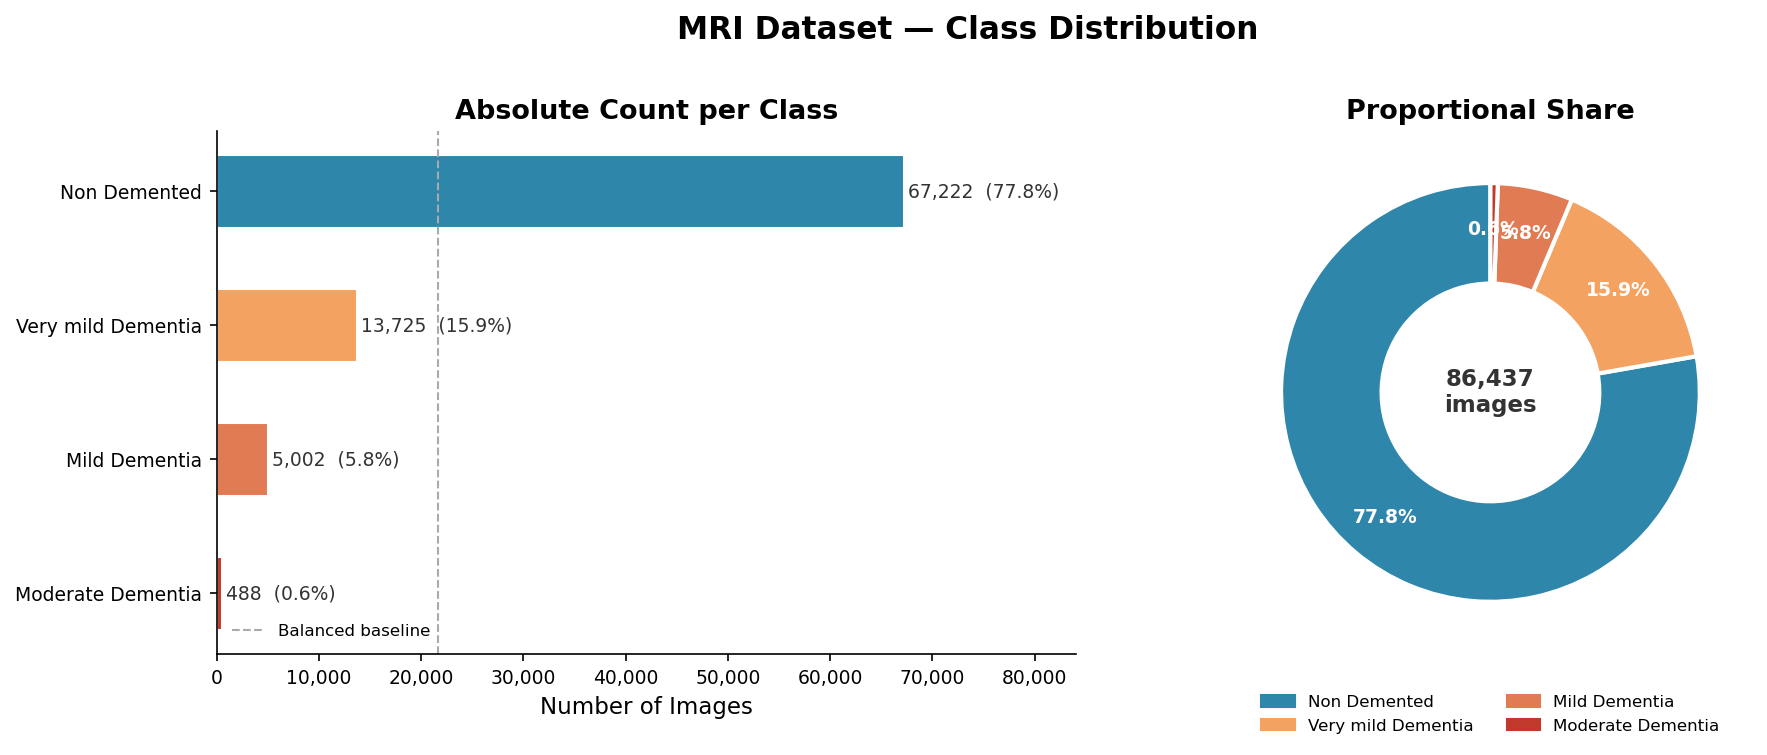


Class imbalance ratio (max/min): 137.75x


,class,count,pct
0,Non Demented,67222,77.77
1,Very mild Dementia,13725,15.88
2,Mild Dementia,5002,5.79
3,Moderate Dementia,488,0.56


In [8]:
def plot_class_distribution(
    inventory_df: pd.DataFrame,
    class_order: list,
    palette: dict,
    save_path: Path | None = None,
) -> pd.DataFrame:
    """
    Two-panel figure:
      Left  – horizontal bar chart with absolute counts & percentages
      Right – donut chart showing proportional share
    """
    counts = inventory_df["class_name"].value_counts().reindex(class_order).fillna(0).astype(int)
    total  = counts.sum()
    pcts   = counts / total * 100

    colors = [palette.get(c, "#999") for c in class_order]

    fig, (ax_bar, ax_donut) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("MRI Dataset — Class Distribution", fontsize=15, fontweight="bold", y=1.01)

    # ── Horizontal bar ─────────────────────────────────────────────────────
    bars = ax_bar.barh(class_order, counts.values, color=colors, edgecolor="white", height=0.55)
    for bar, cnt, pct in zip(bars, counts.values, pcts.values):
        ax_bar.text(
            bar.get_width() + total * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}  ({pct:.1f}%)",
            va="center", ha="left", fontsize=9, color="#333"
        )
    ax_bar.set_xlabel("Number of Images")
    ax_bar.set_title("Absolute Count per Class")
    ax_bar.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_bar.set_xlim(0, counts.max() * 1.25)
    ax_bar.invert_yaxis()
    ax_bar.axvline(total / len(class_order), color="#aaa", ls="--", lw=1, label="Balanced baseline")
    ax_bar.legend(fontsize=8)

    # ── Donut ──────────────────────────────────────────────────────────────
    wedges, texts, autotexts = ax_donut.pie(
        counts.values,
        labels=None,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.78,
        wedgeprops=dict(width=0.48, edgecolor="white", linewidth=2),
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color("white")
        at.set_fontweight("bold")
    ax_donut.text(0, 0, f"{total:,}\nimages", ha="center", va="center",
                  fontsize=11, fontweight="bold", color="#333")
    ax_donut.legend(
        wedges, class_order,
        loc="lower center", bbox_to_anchor=(0.5, -0.18),
        ncol=2, fontsize=8,
        handles=[mpatches.Patch(color=palette.get(c, "#999"), label=c) for c in class_order]
    )
    ax_donut.set_title("Proportional Share")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()

    # Return summary table
    summary = pd.DataFrame({"class": class_order, "count": counts.values, "pct": pcts.values.round(2)})
    imbalance_ratio = counts.max() / counts.min()
    print(f"\nClass imbalance ratio (max/min): {imbalance_ratio:.2f}x")
    return summary


distribution_summary = plot_class_distribution(
    inventory_df, CLASS_ORDER, PALETTE,
    save_path=OUTPUT_DIR / "01_class_distribution.png"
)
distribution_summary

### 📝 Observation — Class Distribution

```
Most frequent class   : Non Demented	 (67222 images,77.77 %)   
Least frequent class  :Moderate Dementia	  ( 488 images, 0.56%)   
Imbalance ratio       : ___x
```

**Implications for training:**  
- A ratio > 3x warrants class-weighted loss or oversampling (SMOTE / random oversample).  
- The dashed line on the bar chart shows what a perfectly balanced dataset would look like.  
- Document which classes are under-represented; they will likely show the lowest per-class recall.

---
## Cell 4 — Sample Image Visualisation

Saved → outputs\02_sample_images.png


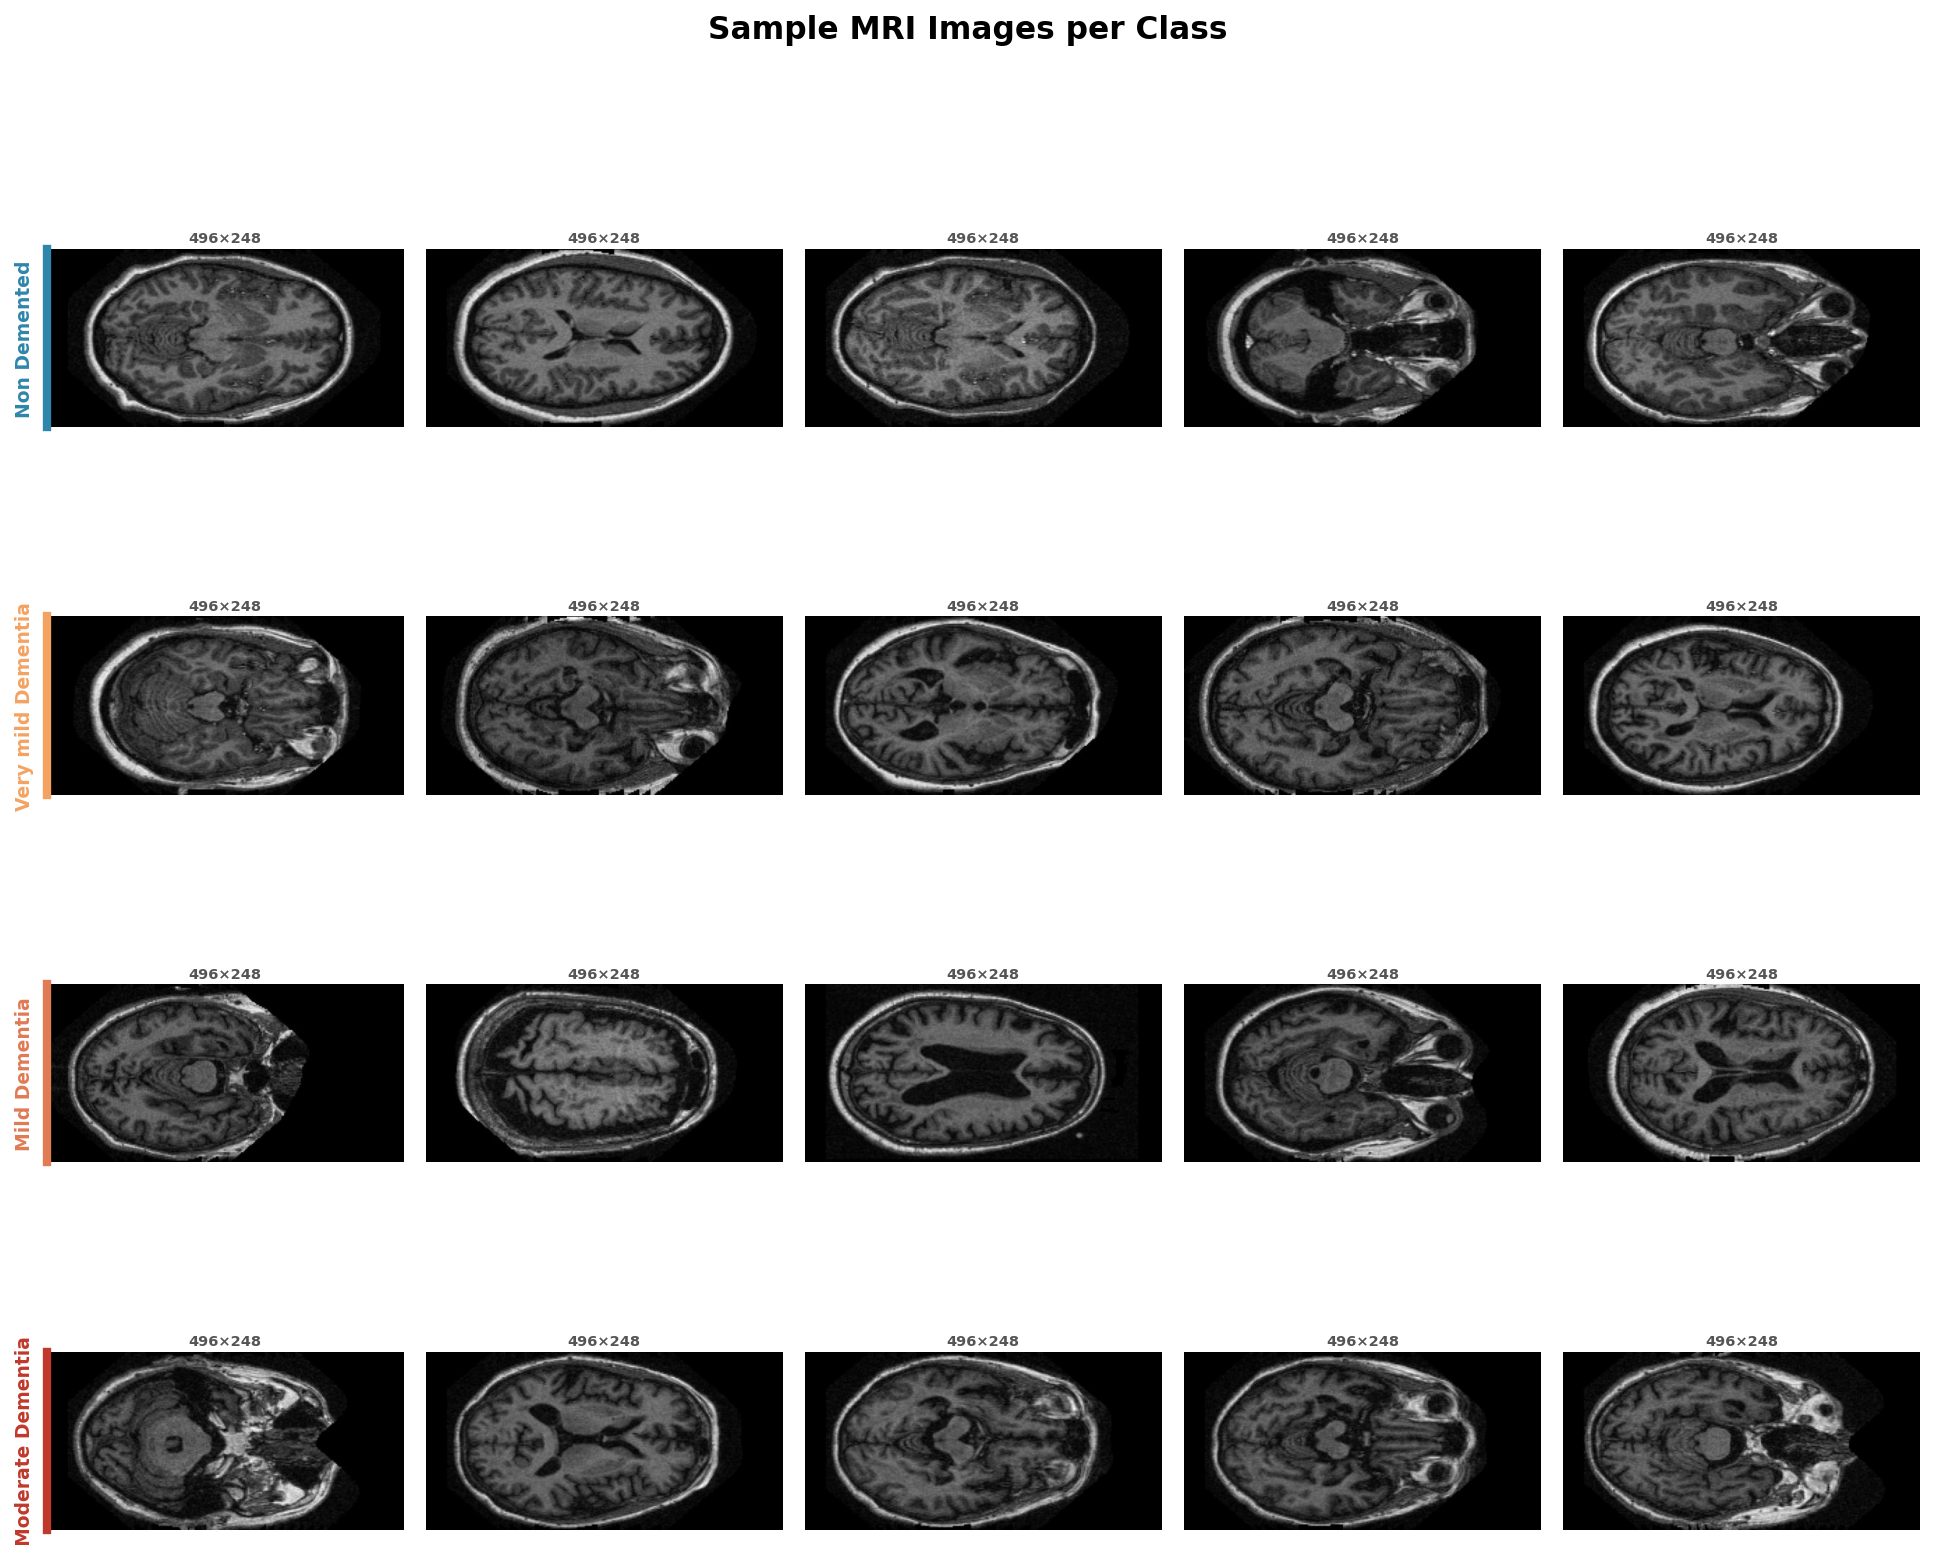

In [9]:
def plot_sample_images(
    inventory_df: pd.DataFrame,
    class_order: list,
    palette: dict,
    n_per_class: int = 5,
    seed: int = 42,
    save_path: Path | None = None,
) -> None:
    """
    Grid: rows = classes, columns = randomly sampled images.
    Each image title shows filename and pixel dimensions.
    A coloured left-spine bar marks the class.
    """
    rng = np.random.default_rng(seed)
    n_classes = len(class_order)

    fig, axes = plt.subplots(
        n_classes, n_per_class,
        figsize=(n_per_class * 2.6, n_classes * 2.8),
    )
    fig.suptitle("Sample MRI Images per Class", fontsize=15, fontweight="bold", y=1.005)

    for row, cls in enumerate(class_order):
        cls_paths = inventory_df.loc[inventory_df["class_name"] == cls, "image_path"].tolist()
        chosen    = rng.choice(cls_paths, size=min(n_per_class, len(cls_paths)), replace=False)
        color     = palette.get(cls, "#999")

        for col, img_path in enumerate(chosen):
            ax = axes[row][col]
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img, cmap="gray" if img.mode == "L" else None)
                ax.set_title(
                    f"{img.size[0]}×{img.size[1]}",
                    fontsize=7, color="#555", pad=3
                )
            except Exception:
                ax.text(0.5, 0.5, "CORRUPT", ha="center", va="center",
                        color="red", fontsize=8, transform=ax.transAxes)

            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

            # Coloured left border for class identity
            if col == 0:
                ax.spines["left"].set_visible(True)
                ax.spines["left"].set_color(color)
                ax.spines["left"].set_linewidth(4)
                ax.set_ylabel(cls, fontsize=9, fontweight="bold", color=color,
                              rotation=90, labelpad=6)

    # Hide any unused axes
    for row in range(n_classes):
        cls_paths = inventory_df.loc[inventory_df["class_name"] == class_order[row], "image_path"].tolist()
        for col in range(len(cls_paths), n_per_class):
            axes[row][col].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


plot_sample_images(
    inventory_df, CLASS_ORDER, PALETTE,
    n_per_class=5,
    save_path=OUTPUT_DIR / "02_sample_images.png"
)

### 📝 Observation — Sample Images

Inspect the grid and record:

| Class | Visual appearance | Distinguishing features |
|-------|-------------------|-------------------------|
| Non Demented | | |
| Very mild Dementia | | |
| Mild Dementia | | |
| Moderate Dementia | | |

**Key questions:**  
- Are the images consistently skull-stripped or raw?  
- Is slice orientation (axial / sagittal / coronal) uniform across classes?  
- Are there visible watermarks, borders, or text overlays?

---
## Cell 5 — Image Dimension Audit

In [10]:
def audit_image_dimensions(
    inventory_df: pd.DataFrame,
    sample_size: int | None = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Open every image (or a random sample) and record:
      width, height, channels, mode, file_size_kb
    Skips corrupted files gracefully.
    """
    df = inventory_df.copy()
    if sample_size and sample_size < len(df):
        df = df.sample(n=sample_size, random_state=seed).reset_index(drop=True)
        print(f"Sampling {sample_size} images for dimension audit …")
    else:
        print(f"Auditing all {len(df):,} images …")

    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Dimension audit"):
        path = row["image_path"]
        rec  = {
            "image_path": path,
            "class_name": row["class_name"],
            "file_size_kb": round(Path(path).stat().st_size / 1024, 2)
        }
        try:
            with Image.open(path) as img:
                rec["width"]    = img.width
                rec["height"]   = img.height
                rec["mode"]     = img.mode
                rec["channels"] = len(img.getbands())
                rec["corrupt"]  = False
        except Exception as e:
            rec.update({"width": None, "height": None, "mode": None,
                        "channels": None, "corrupt": True})
        records.append(rec)

    return pd.DataFrame(records)


dim_df = audit_image_dimensions(inventory_df)  # set sample_size=500 for large datasets

print("\n── Dimension summary ─────────────────────────")
print(dim_df[["width", "height", "file_size_kb"]].describe().round(2).to_string())

print("\n── Unique (W×H) sizes ────────────────────────")
size_counts = (
    dim_df.dropna(subset=["width"])
          .assign(wh=dim_df["width"].astype(str) + "×" + dim_df["height"].astype(str))
          ["wh"].value_counts()
)
print(size_counts.to_string())

print("\n── Colour modes ──────────────────────────────")
print(dim_df["mode"].value_counts().to_string())

Auditing all 86,437 images …


Dimension audit:   0%|          | 0/86437 [00:00<?, ?it/s]


── Dimension summary ─────────────────────────
         width   height  file_size_kb
count  86437.0  86437.0      86437.00
mean     496.0    248.0         15.32
std        0.0      0.0          1.40
min      496.0    248.0          7.88
25%      496.0    248.0         14.51
50%      496.0    248.0         15.35
75%      496.0    248.0         16.17
max      496.0    248.0         21.35

── Unique (W×H) sizes ────────────────────────
wh
496×248    86437

── Colour modes ──────────────────────────────
mode
RGB    86437


Saved → outputs\03_dimension_distributions.png


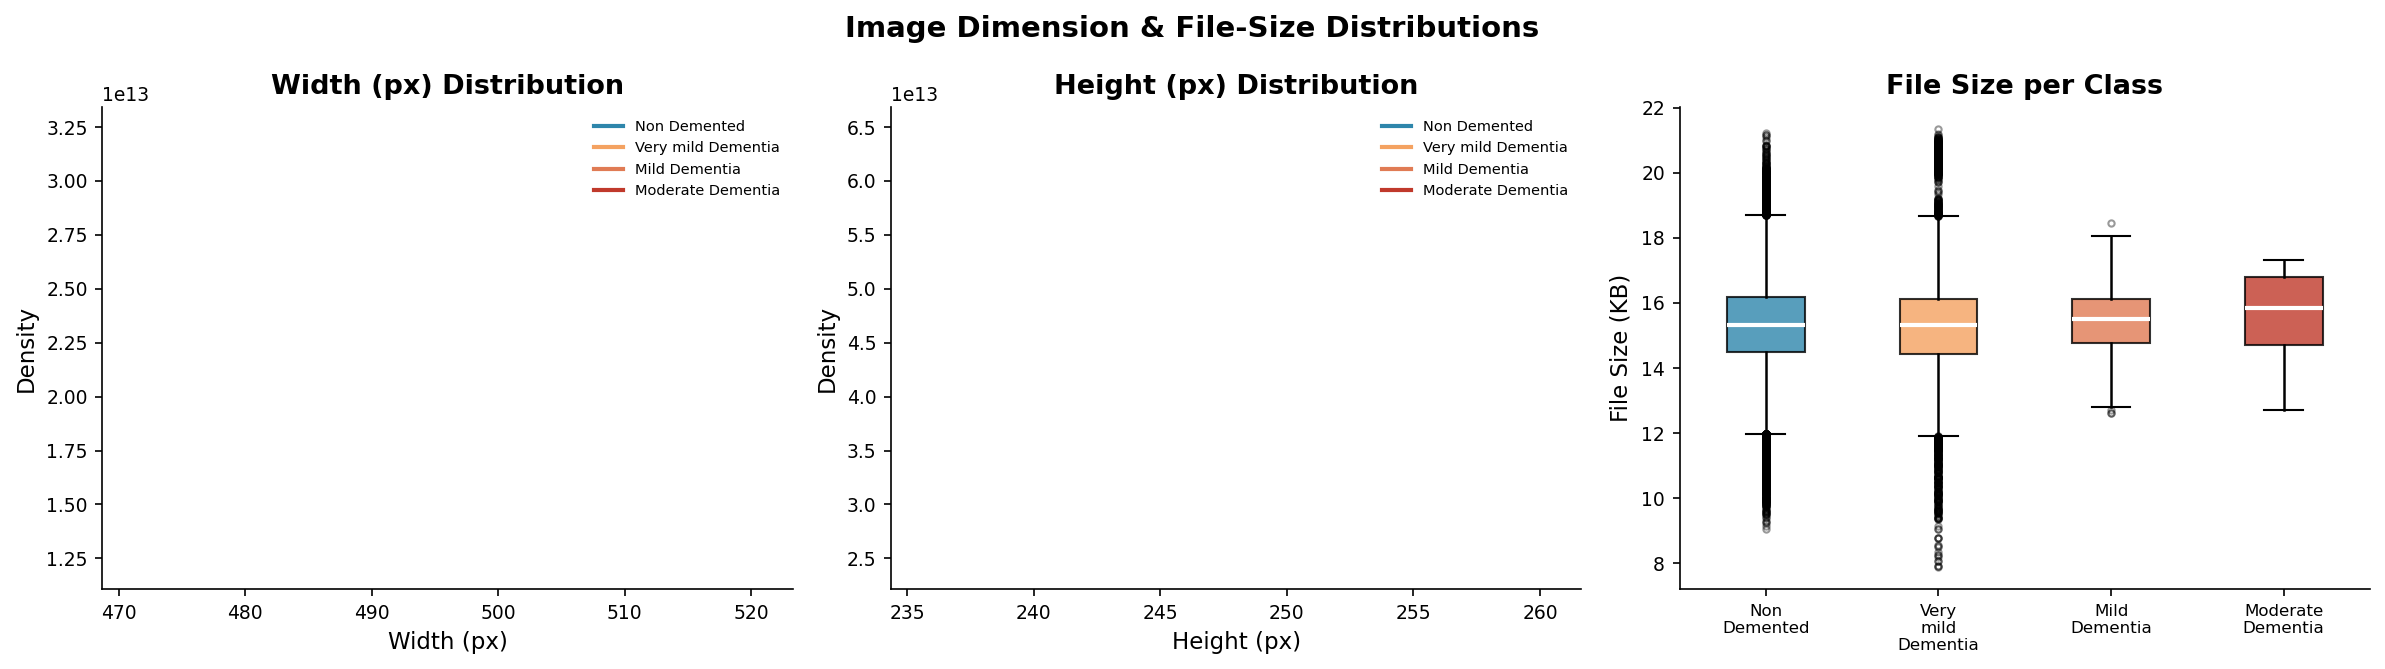

In [19]:
def plot_dimension_distributions(
    dim_df: pd.DataFrame,
    palette: dict,
    class_order: list,
    save_path: Path | None = None,
) -> None:
    """
    Three sub-plots:
      Top-left  – width distribution by class (KDE)
      Top-right – height distribution by class (KDE)
      Bottom    – file size distribution by class (box + strip)
    """
    valid = dim_df.dropna(subset=["width", "height"])
    colors = [palette.get(c, "#999") for c in class_order]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle("Image Dimension & File-Size Distributions", fontsize=14, fontweight="bold")

    for ax, dim, label in zip(axes[:2], ["width", "height"], ["Width (px)", "Height (px)"]):
        for cls, color in zip(class_order, colors):
            vals = valid.loc[valid["class_name"] == cls, dim]
            if len(vals) > 1:
                vals.plot.kde(ax=ax, label=cls, color=color, lw=2)
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.set_title(f"{label} Distribution")
        ax.legend(fontsize=7)

    # File-size box plot
    ax_sz = axes[2]
    data_by_class = [valid.loc[valid["class_name"] == c, "file_size_kb"].values for c in class_order]
    bp = ax_sz.boxplot(
        data_by_class, patch_artist=True,
        medianprops=dict(color="white", lw=2),
        whiskerprops=dict(lw=1.2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax_sz.set_xticklabels([c.replace(" ", "\n") for c in class_order], fontsize=8)
    ax_sz.set_ylabel("File Size (KB)")
    ax_sz.set_title("File Size per Class")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


plot_dimension_distributions(
    dim_df, PALETTE, CLASS_ORDER,
    save_path=OUTPUT_DIR / "03_dimension_distributions.png"
)

### 📝 Observation — Image Dimensions

```
Dominant resolution   : ___×___  px  (___% of images)
Secondary resolutions : ___
Colour modes          : ___  (RGB / L / RGBA …)
File size range       : ___ – ___ KB  (mean ___ KB)
```

**Implications:**  
- If multiple resolutions exist, confirm the `Resize` transform is applied before training.  
- Images in `L` (grayscale) mode must be converted to `RGB` for ResNet (`convert('RGB')` in the transform).  
- Outlier file sizes may indicate corrupted or near-blank scans — cross-check with Cell 6.

---
## Cell 6 — Corrupted Image Detection

In [12]:
def detect_corrupted_images(
    inventory_df: pd.DataFrame,
    blank_threshold: float = 5.0,
) -> pd.DataFrame:
    """
    Flag images that are:
      1. Unreadable (PIL raises an error)
      2. Blank / near-blank (std-dev of pixel values < threshold)
      3. Truncated (PIL verify() fails)

    Parameters
    ----------
    blank_threshold : float
        Pixel std-dev below which an image is considered blank.
        128-level grayscale noise typically has std > 30; near-black
        or all-white scans fall below ~5.
    """
    records = []

    for _, row in tqdm(inventory_df.iterrows(), total=len(inventory_df), desc="Corruption check"):
        path = row["image_path"]
        rec  = {
            "image_path" : path,
            "class_name" : row["class_name"],
            "filename"   : row["filename"],
            "unreadable" : False,
            "truncated"  : False,
            "blank"      : False,
            "pixel_std"  : None,
            "issue"      : None,
        }

        try:
            # Test 1 — unreadable
            img = Image.open(path)
            img.load()

            # Test 2 — truncated (verify consumes the file object; re-open)
            with Image.open(path) as v:
                try:
                    v.verify()
                except Exception:
                    rec["truncated"] = True
                    rec["issue"]     = "truncated"

            # Test 3 — blank
            arr = np.array(img.convert("L"), dtype=np.float32)
            std = float(arr.std())
            rec["pixel_std"] = round(std, 3)
            if std < blank_threshold:
                rec["blank"]  = True
                rec["issue"]  = rec["issue"] or "blank"

        except (UnidentifiedImageError, OSError, Exception) as e:
            rec["unreadable"] = True
            rec["issue"]      = f"unreadable: {type(e).__name__}"

        records.append(rec)

    result = pd.DataFrame(records)
    flagged = result[result["issue"].notna()]

    print(f"{'─'*52}")
    print(f"  Total images checked : {len(result):,}")
    print(f"  Unreadable           : {result['unreadable'].sum()}")
    print(f"  Truncated            : {result['truncated'].sum()}")
    print(f"  Blank / near-blank   : {result['blank'].sum()}  (std < {blank_threshold})")
    print(f"  Total flagged        : {len(flagged)}")
    print(f"{'─'*52}")

    if len(flagged):
        print("\nFlagged images:")
        display(flagged[["class_name", "filename", "issue", "pixel_std"]])

    return result


corruption_df = detect_corrupted_images(inventory_df, blank_threshold=5.0)

Corruption check:   0%|          | 0/86437 [00:00<?, ?it/s]

────────────────────────────────────────────────────
  Total images checked : 86,437
  Unreadable           : 0
  Truncated            : 0
  Blank / near-blank   : 0  (std < 5.0)
  Total flagged        : 0
────────────────────────────────────────────────────


Saved → outputs\04_pixel_std_distribution.png


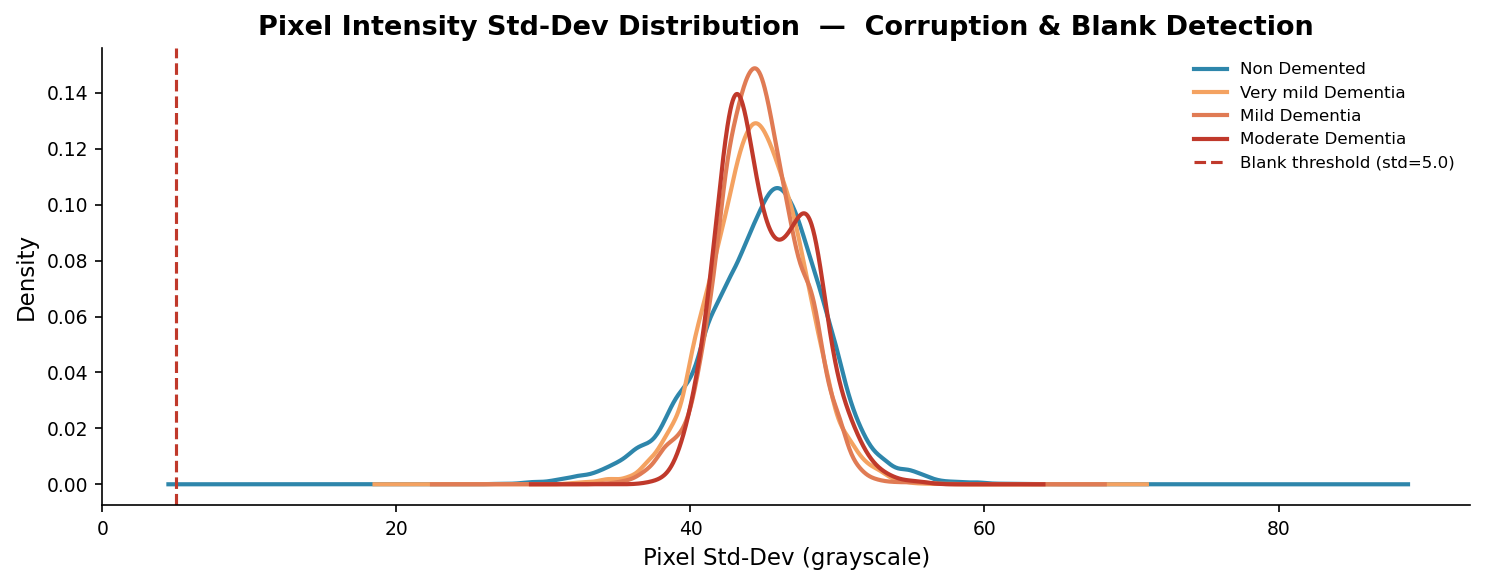

In [20]:
def plot_pixel_std_distribution(
    corruption_df: pd.DataFrame,
    palette: dict,
    class_order: list,
    blank_threshold: float = 5.0,
    save_path: Path | None = None,
) -> None:
    """
    KDE of pixel std-dev per class.
    A vertical red dashed line marks the blank-detection threshold.
    """
    valid = corruption_df.dropna(subset=["pixel_std"])

    fig, ax = plt.subplots(figsize=(10, 4))
    for cls in class_order:
        vals = valid.loc[valid["class_name"] == cls, "pixel_std"]
        if len(vals) > 1:
            vals.plot.kde(ax=ax, label=cls, color=palette.get(cls, "#999"), lw=2)

    ax.axvline(blank_threshold, color="#C0392B", ls="--", lw=1.5,
               label=f"Blank threshold (std={blank_threshold})")
    ax.set_xlabel("Pixel Std-Dev (grayscale)")
    ax.set_ylabel("Density")
    ax.set_title("Pixel Intensity Std-Dev Distribution  —  Corruption & Blank Detection")
    ax.legend(fontsize=8)
    ax.set_xlim(left=0)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


plot_pixel_std_distribution(
    corruption_df, PALETTE, CLASS_ORDER, blank_threshold=5.0,
    save_path=OUTPUT_DIR / "04_pixel_std_distribution.png"
)

### 📝 Observation — Corrupted Images

```
Unreadable images    : ___
Truncated images     : ___
Blank images (std<5) : ___
Total flagged        : ___  (___% of dataset)
```

**Action items:**  
- Remove flagged files before training, or add a `try/except` in the Dataset `__getitem__` to skip them.  
- Verify blank images are not valid near-black slices from the edge of the brain volume.  
- Re-run with `blank_threshold=10.0` if the KDE peak sits close to the default threshold.

---
## Cell 7 — Pixel-Level Statistics

In [14]:
def compute_pixel_statistics(
    inventory_df: pd.DataFrame,
    class_order: list,
    sample_size: int = 300,
    target_size: tuple[int, int] = (128, 128),
    seed: int = 42,
) -> pd.DataFrame:
    """
    Compute per-image mean and std of pixel values (normalised 0–1),
    then aggregate per class.

    Uses a random sample for speed on large datasets.
    """
    df = inventory_df.copy()
    if sample_size < len(df):
        df = df.groupby("class_name", group_keys=False).apply(
            lambda g: g.sample(min(len(g), sample_size // len(class_order)), random_state=seed)
        ).reset_index(drop=True)
        print(f"Sampling {len(df)} images for pixel statistics …")

    stats = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Pixel stats"):
        try:
            img  = Image.open(row["image_path"]).convert("L").resize(target_size)
            arr  = np.array(img, dtype=np.float32) / 255.0
            stats.append({
                "class_name": row["class_name"],
                "mean":       float(arr.mean()),
                "std":        float(arr.std()),
                "min":        float(arr.min()),
                "max":        float(arr.max()),
                "pct5":       float(np.percentile(arr, 5)),
                "pct95":      float(np.percentile(arr, 95)),
            })
        except Exception:
            pass

    stats_df = pd.DataFrame(stats)

    print("\n── Per-class pixel stats (mean ± std of the per-image means) ──")
    agg = (
        stats_df.groupby("class_name")[["mean", "std"]]
                .agg(["mean", "std"])
                .round(4)
    )
    print(agg.reindex(class_order).to_string())

    return stats_df


pixel_stats_df = compute_pixel_statistics(inventory_df, CLASS_ORDER, sample_size=300)

Sampling 300 images for pixel statistics …


Pixel stats:   0%|          | 0/300 [00:00<?, ?it/s]


── Per-class pixel stats (mean ± std of the per-image means) ──
                      mean             std        
                      mean     std    mean     std
class_name                                        
Non Demented        0.1666  0.0290  0.1742  0.0176
Very mild Dementia  0.1583  0.0211  0.1704  0.0127
Mild Dementia       0.1586  0.0177  0.1715  0.0111
Moderate Dementia   0.1528  0.0181  0.1748  0.0118


Saved → outputs\05_pixel_statistics.png


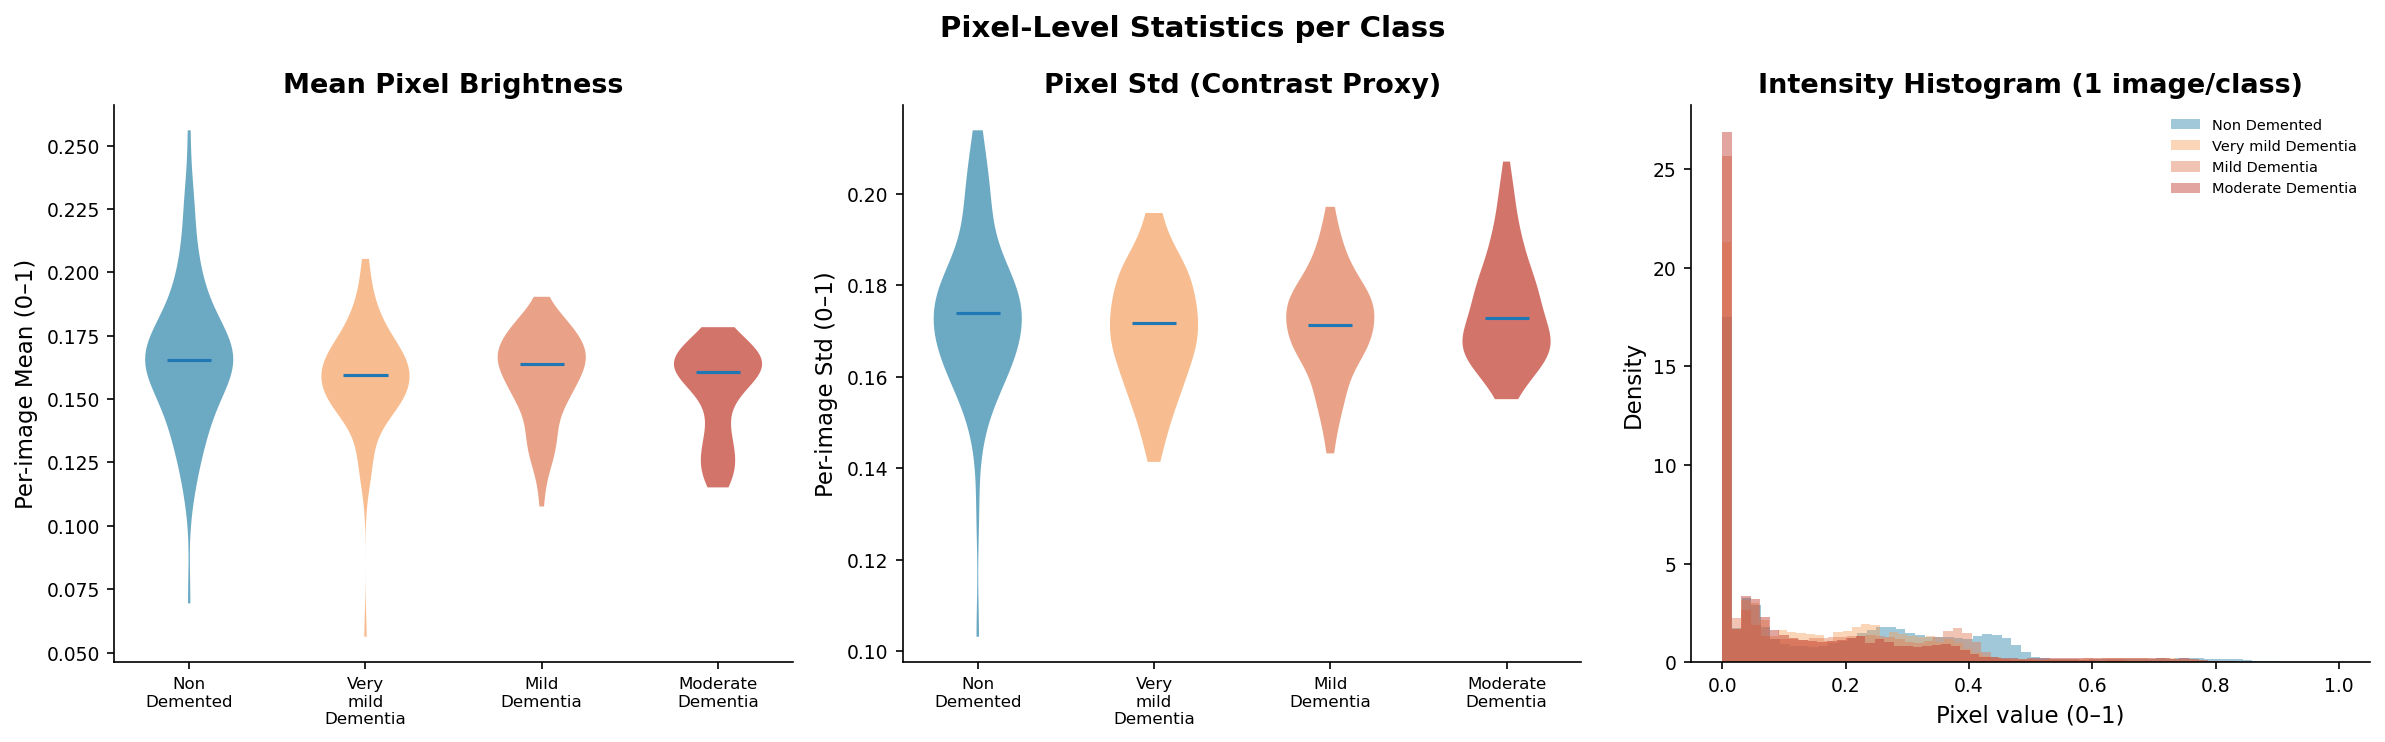

In [15]:
def plot_pixel_statistics(
    pixel_stats_df: pd.DataFrame,
    inventory_df: pd.DataFrame,
    class_order: list,
    palette: dict,
    save_path: Path | None = None,
) -> None:
    """
    Three-panel figure:
      Left   – violin of per-image mean pixel value by class
      Centre – violin of per-image std by class
      Right  – channel histograms for one random image per class
    """
    colors = [palette.get(c, "#999") for c in class_order]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Pixel-Level Statistics per Class", fontsize=14, fontweight="bold")

    # Violin: mean brightness
    data_mean = [pixel_stats_df.loc[pixel_stats_df["class_name"] == c, "mean"].values for c in class_order]
    vp1 = axes[0].violinplot(data_mean, showmedians=True, showextrema=False)
    for body, color in zip(vp1["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    axes[0].set_xticks(range(1, len(class_order) + 1))
    axes[0].set_xticklabels([c.replace(" ", "\n") for c in class_order], fontsize=8)
    axes[0].set_ylabel("Per-image Mean (0–1)")
    axes[0].set_title("Mean Pixel Brightness")

    # Violin: std
    data_std = [pixel_stats_df.loc[pixel_stats_df["class_name"] == c, "std"].values for c in class_order]
    vp2 = axes[1].violinplot(data_std, showmedians=True, showextrema=False)
    for body, color in zip(vp2["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    axes[1].set_xticks(range(1, len(class_order) + 1))
    axes[1].set_xticklabels([c.replace(" ", "\n") for c in class_order], fontsize=8)
    axes[1].set_ylabel("Per-image Std (0–1)")
    axes[1].set_title("Pixel Std (Contrast Proxy)")

    # Channel histogram: one random image per class overlaid
    rng = np.random.default_rng(0)
    ax_h = axes[2]
    for cls, color in zip(class_order, colors):
        cls_paths = inventory_df.loc[inventory_df["class_name"] == cls, "image_path"].tolist()
        path = rng.choice(cls_paths)
        try:
            arr = np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
            ax_h.hist(arr.ravel(), bins=64, alpha=0.45, color=color,
                      label=cls, density=True, histtype="stepfilled")
        except Exception:
            pass
    ax_h.set_xlabel("Pixel value (0–1)")
    ax_h.set_ylabel("Density")
    ax_h.set_title("Intensity Histogram (1 image/class)")
    ax_h.legend(fontsize=7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


plot_pixel_statistics(
    pixel_stats_df, inventory_df, CLASS_ORDER, PALETTE,
    save_path=OUTPUT_DIR / "05_pixel_statistics.png"
)

### 📝 Observation — Pixel Statistics

```
Dataset-level mean brightness  : ___   (ideal for pre-training: ~0.45 for ImageNet)
Dataset-level mean std         : ___
Class with lowest mean         : ___   (darkest scans on average)
Class with highest std         : ___   (most contrast variability)
```

**Implications for normalisation:**  
- If mean brightness differs across classes, brightness-based features will leak class information — expected and acceptable.  
- Use dataset-specific `transforms.Normalize(mean, std)` instead of ImageNet values if pixel distributions deviate substantially from ImageNet's 0.485/0.229.  
- High within-class std variance suggests scanner heterogeneity — consider histogram equalisation.

---
## Cell 8 — Publication-Quality Summary Dashboard

Saved → outputs\06_summary_dashboard.png


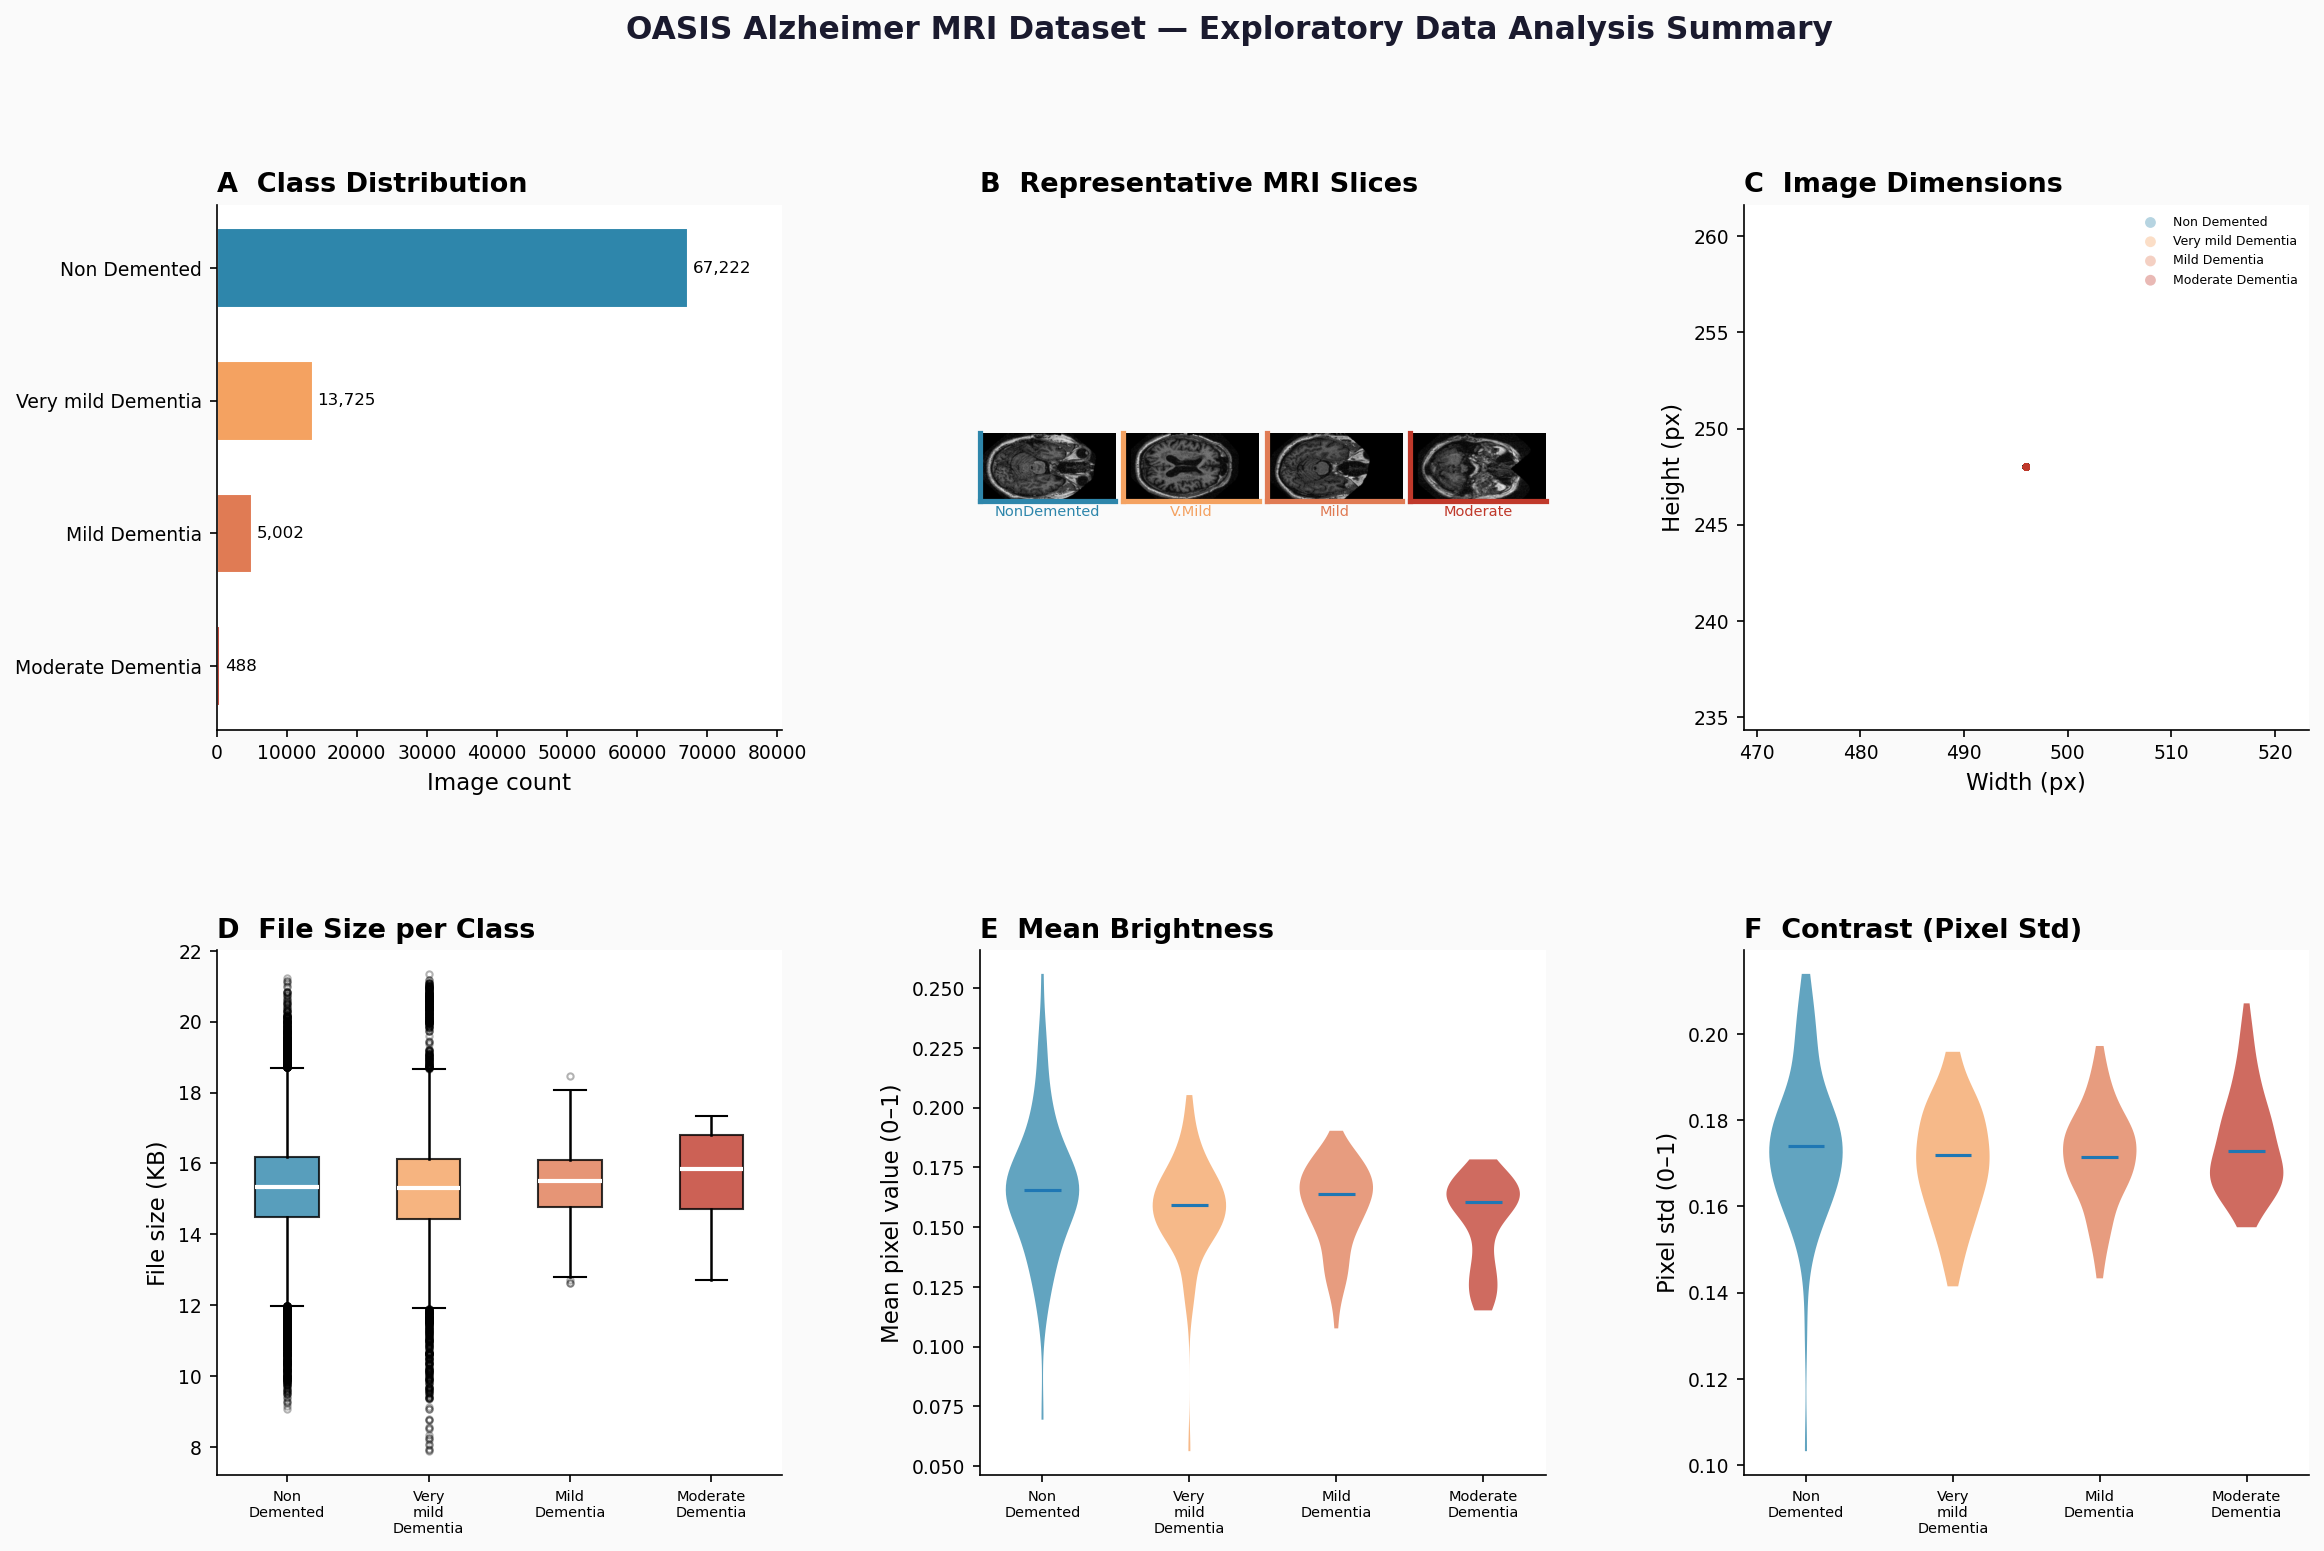

In [21]:
def plot_summary_dashboard(
    inventory_df: pd.DataFrame,
    dim_df: pd.DataFrame,
    corruption_df: pd.DataFrame,
    pixel_stats_df: pd.DataFrame,
    class_order: list,
    palette: dict,
    save_path: Path | None = None,
) -> None:
    """
    Single publication-ready figure (2×3 grid) combining:
      A – class distribution (bar)
      B – sample MRI thumbnails (one per class)
      C – image size scatter
      D – file-size box
      E – pixel mean violin
      F – pixel std violin
    """
    colors = [palette.get(c, "#999") for c in class_order]

    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor("#FAFAFA")

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.42,
        wspace=0.35,
    )

    ax_a = fig.add_subplot(gs[0, 0])   # A – class counts
    ax_b = fig.add_subplot(gs[0, 1])   # B – thumbnails
    ax_c = fig.add_subplot(gs[0, 2])   # C – size scatter
    ax_d = fig.add_subplot(gs[1, 0])   # D – file size box
    ax_e = fig.add_subplot(gs[1, 1])   # E – mean brightness violin
    ax_f = fig.add_subplot(gs[1, 2])   # F – pixel std violin

    LABEL_KW = dict(fontsize=11, fontweight="bold", color="#222",
                    transform=None, va="top")

    # ── A: Class distribution bar ──────────────────────────────────────────
    counts = inventory_df["class_name"].value_counts().reindex(class_order).fillna(0)
    bars = ax_a.barh(class_order, counts.values, color=colors, edgecolor="white", height=0.6)
    for bar, cnt in zip(bars, counts.values):
        ax_a.text(bar.get_width() + counts.max() * 0.01,
                  bar.get_y() + bar.get_height() / 2,
                  f"{int(cnt):,}", va="center", fontsize=8)
    ax_a.set_xlabel("Image count")
    ax_a.set_title("A  Class Distribution", loc="left", fontweight="bold")
    ax_a.invert_yaxis()
    ax_a.set_xlim(0, counts.max() * 1.2)
    ax_a.spines[["top", "right"]].set_visible(False)

    # ── B: One thumbnail per class ─────────────────────────────────────────
    ax_b.set_title("B  Representative MRI Slices", loc="left", fontweight="bold")
    ax_b.axis("off")

    inner = gridspec.GridSpecFromSubplotSpec(
        1, len(class_order), subplot_spec=gs[0, 1], wspace=0.06
    )
    rng = np.random.default_rng(7)
    for i, (cls, color) in enumerate(zip(class_order, colors)):
        axi = fig.add_subplot(inner[i])
        paths = inventory_df.loc[inventory_df["class_name"] == cls, "image_path"].tolist()
        try:
            img = Image.open(rng.choice(paths)).convert("RGB")
            axi.imshow(img)
        except Exception:
            axi.text(0.5, 0.5, "ERR", ha="center", va="center", color="red", transform=axi.transAxes)
        for spine in axi.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        axi.set_xticks([])
        axi.set_yticks([])
        short = cls.replace(" Dementia", "").replace("Non ", "Non").replace("Very mild", "V.Mild")
        axi.set_xlabel(short, fontsize=7, color=color, labelpad=2)

    # ── C: Width vs Height scatter ─────────────────────────────────────────
    valid_dim = dim_df.dropna(subset=["width", "height"])
    for cls, color in zip(class_order, colors):
        sub = valid_dim[valid_dim["class_name"] == cls]
        ax_c.scatter(sub["width"], sub["height"], color=color, alpha=0.35,
                     s=12, label=cls, edgecolors="none")
    ax_c.set_xlabel("Width (px)")
    ax_c.set_ylabel("Height (px)")
    ax_c.set_title("C  Image Dimensions", loc="left", fontweight="bold")
    ax_c.legend(fontsize=6, markerscale=1.5)
    ax_c.spines[["top", "right"]].set_visible(False)

    # ── D: File size boxplot ───────────────────────────────────────────────
    fs_data = [valid_dim.loc[valid_dim["class_name"] == c, "file_size_kb"].values for c in class_order]
    bp = ax_d.boxplot(fs_data, patch_artist=True,
                      medianprops=dict(color="white", lw=2),
                      whiskerprops=dict(lw=1.2),
                      flierprops=dict(marker="o", ms=3, alpha=0.3))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax_d.set_xticklabels([c.replace(" ", "\n") for c in class_order], fontsize=7)
    ax_d.set_ylabel("File size (KB)")
    ax_d.set_title("D  File Size per Class", loc="left", fontweight="bold")
    ax_d.spines[["top", "right"]].set_visible(False)

    # ── E: Mean brightness violin ─────────────────────────────────────────
    mean_data = [pixel_stats_df.loc[pixel_stats_df["class_name"] == c, "mean"].values for c in class_order]
    vp = ax_e.violinplot(mean_data, showmedians=True, showextrema=False)
    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.75)
    ax_e.set_xticks(range(1, len(class_order) + 1))
    ax_e.set_xticklabels([c.replace(" ", "\n") for c in class_order], fontsize=7)
    ax_e.set_ylabel("Mean pixel value (0–1)")
    ax_e.set_title("E  Mean Brightness", loc="left", fontweight="bold")
    ax_e.spines[["top", "right"]].set_visible(False)

    # ── F: Pixel std violin ───────────────────────────────────────────────
    std_data = [pixel_stats_df.loc[pixel_stats_df["class_name"] == c, "std"].values for c in class_order]
    vp2 = ax_f.violinplot(std_data, showmedians=True, showextrema=False)
    for body, color in zip(vp2["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.75)
    ax_f.set_xticks(range(1, len(class_order) + 1))
    ax_f.set_xticklabels([c.replace(" ", "\n") for c in class_order], fontsize=7)
    ax_f.set_ylabel("Pixel std (0–1)")
    ax_f.set_title("F  Contrast (Pixel Std)", loc="left", fontweight="bold")
    ax_f.spines[["top", "right"]].set_visible(False)

    # ── Super-title ────────────────────────────────────────────────────────
    fig.text(
        0.5, 0.995,
        "OASIS Alzheimer MRI Dataset — Exploratory Data Analysis Summary",
        ha="center", va="top", fontsize=15, fontweight="bold", color="#1a1a2e"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    if save_path:
        fig.savefig(save_path, facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")
    plt.show()


plot_summary_dashboard(
    inventory_df, dim_df, corruption_df, pixel_stats_df,
    CLASS_ORDER, PALETTE,
    save_path=OUTPUT_DIR / "06_summary_dashboard.png"
)

### 📝 Observation — Summary Dashboard

This figure consolidates all six analyses into one publication-ready panel suitable for inclusion in a paper or report.

**Key take-aways to record here:**

| Panel | Finding | Action |
|-------|---------|--------|
| A — Class distribution | | |
| B — Sample images | | |
| C — Dimensions | | |
| D — File size | | |
| E — Brightness | | |
| F — Contrast | | |

---
## Cell 9 — Dataset Statistics Report

In [17]:
def print_dataset_report(
    inventory_df: pd.DataFrame,
    dim_df: pd.DataFrame,
    corruption_df: pd.DataFrame,
    pixel_stats_df: pd.DataFrame,
    class_order: list,
) -> pd.DataFrame:
    """
    Print a concise structured report and return a per-class summary DataFrame
    suitable for export as a LaTeX / Markdown table.
    """
    counts = inventory_df["class_name"].value_counts().reindex(class_order).fillna(0).astype(int)
    total  = counts.sum()

    valid  = dim_df.dropna(subset=["width", "height"])
    n_corrupt = corruption_df["issue"].notna().sum()

    rows = []
    for cls in class_order:
        c_dim = valid[valid["class_name"] == cls]
        c_pix = pixel_stats_df[pixel_stats_df["class_name"] == cls]
        rows.append({
            "Class"           : cls,
            "N"               : int(counts[cls]),
            "%"               : round(counts[cls] / total * 100, 1),
            "W_mean"          : round(c_dim["width"].mean(),  1) if len(c_dim) else None,
            "H_mean"          : round(c_dim["height"].mean(), 1) if len(c_dim) else None,
            "FileKB_median"   : round(c_dim["file_size_kb"].median(), 1) if len(c_dim) else None,
            "PxMean"          : round(c_pix["mean"].mean(), 4) if len(c_pix) else None,
            "PxStd"           : round(c_pix["std"].mean(),  4) if len(c_pix) else None,
        })

    report_df = pd.DataFrame(rows)

    sep = "═" * 62
    print(sep)
    print("  OASIS Alzheimer MRI — Dataset Statistics Report")
    print(sep)
    print(f"  Total images       : {total:,}")
    print(f"  Number of classes  : {len(class_order)}")
    print(f"  Corrupted / blank  : {n_corrupt}")
    print(f"  Unique subjects    : {inventory_df['subject_id'].nunique()} "
          f"(excl. UNKNOWN: {(inventory_df['subject_id'] != 'UNKNOWN').sum()})")
    print(sep)
    print(report_df.to_string(index=False))
    print(sep)
    print(f"  Imbalance ratio    : {counts.max()/counts.min():.2f}x  "
          f"({counts.idxmax()} vs {counts.idxmin()})")
    print(sep)

    # Save as CSV
    out = OUTPUT_DIR / "dataset_statistics.csv"
    report_df.to_csv(out, index=False)
    print(f"\nReport saved → {out}")

    return report_df


report_df = print_dataset_report(
    inventory_df, dim_df, corruption_df, pixel_stats_df, CLASS_ORDER
)

══════════════════════════════════════════════════════════════
  OASIS Alzheimer MRI — Dataset Statistics Report
══════════════════════════════════════════════════════════════
  Total images       : 86,437
  Number of classes  : 4
  Corrupted / blank  : 0
  Unique subjects    : 366 (excl. UNKNOWN: 86437)
══════════════════════════════════════════════════════════════
             Class     N    %  W_mean  H_mean  FileKB_median  PxMean  PxStd
      Non Demented 67222 77.8   496.0   248.0           15.3  0.1666 0.1742
Very mild Dementia 13725 15.9   496.0   248.0           15.3  0.1583 0.1704
     Mild Dementia  5002  5.8   496.0   248.0           15.5  0.1586 0.1715
 Moderate Dementia   488  0.6   496.0   248.0           15.8  0.1528 0.1748
══════════════════════════════════════════════════════════════
  Imbalance ratio    : 137.75x  (Non Demented vs Moderate Dementia)
══════════════════════════════════════════════════════════════

Report saved → outputs\dataset_statistics.csv


### 📝 Final Observation — Pre-Training Checklist

Use this checklist before handing the dataset off to the training pipeline:

- [ ] All four classes confirmed present  
- [ ] Corrupted / blank images removed or handled in `__getitem__`  
- [ ] Images resized to a uniform resolution (e.g. 224×224)  
- [ ] Grayscale images converted to RGB (`transforms.Grayscale(3)` or `.convert('RGB')`)  
- [ ] Class-imbalance mitigation strategy chosen (WeightedRandomSampler / weighted loss / augmentation)  
- [ ] Normalisation constants computed from this dataset (not ImageNet defaults) if distributions differ substantially  
- [ ] Train / val / test split is stratified by class *and* by subject ID (avoid data leakage from the same subject appearing in both train and test)